<a href="https://colab.research.google.com/github/utkarshhg/3_d_in-java/blob/main/fake_news_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [157]:
import numpy as np
import pandas as pd

In [158]:
import pandas as pd

print("Loading Fake.csv...")
# Use the python engine to skip bad lines, but KEEP quotes enabled
temp_df_false = pd.read_csv("/content/Fake.csv", engine="python", on_bad_lines="skip")
temp_df_false['sentiment'] = 0

print("Loading True.csv...")
temp_df_true = pd.read_csv("/content/True.csv", engine="python", on_bad_lines="skip")
temp_df_true['sentiment'] = 1

print("Combining and shuffling...")
temp_df = pd.concat([temp_df_false, temp_df_true], axis=0)
temp_df = temp_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Let's check the data to make sure the text is actually there this time!
print("\nSuccess! Here is a sample of your text:")
temp_df[['title', 'text', 'sentiment']].sample(5)

Loading Fake.csv...
Loading True.csv...
Combining and shuffling...

Success! Here is a sample of your text:


,title,text,sentiment
14633,Plan for U.S. tax increase on rich not being c...,WASHINGTON (Reuters) - The Trump administratio...,1
33293,“BLOOD ON THEIR HANDS” FOR VOTING RIGHTS: The ...,It s time to stop hitting the snooze button Am...,0
10252,U.S. appeals court voids forfeiture of Iran-li...,NEW YORK (Reuters) - A federal appeals court s...,1
34775,Factbox: Trump to meet with retired General Pe...,(Reuters) - U.S. Republican President-elect Do...,1
36514,Death of youth leader stirs tensions in Ivory ...,ABIDJAN (Reuters) - Protesters clashed with po...,1


In [159]:
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      44898 non-null  object
 1   text       44898 non-null  object
 2   subject    44898 non-null  object
 3   date       44898 non-null  object
 4   sentiment  44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [160]:
temp_df['sentiment'].value_counts()

,count
sentiment,
0,23481
1,21417


In [161]:
temp_df.drop_duplicates()

,title,text,subject,date,sentiment
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1
...,...,...,...,...,...
44893,UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...,,politics,"Mar 27, 2017",0
44894,PM May seeks to ease Japan's Brexit fears duri...,LONDON/TOKYO (Reuters) - British Prime Ministe...,worldnews,"August 29, 2017",1
44895,Merkel: Difficult German coalition talks can r...,BERLIN (Reuters) - Chancellor Angela Merkel sa...,worldnews,"November 16, 2017",1
44896,Trump Stole An Idea From North Korean Propaga...,Jesus f*cking Christ our President* is a moron...,News,"July 14, 2017",0


In [162]:
temp_df['subject'].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [163]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: group counts of sentiment per subject
grouped = temp_df.groupby(['subject','sentiment']).size().unstack(fill_value=0)

print(grouped)


sentiment           0      1
subject                     
Government News  1570      0
Middle-east       778      0
News             9050      0
US_News           783      0
left-news        4459      0
politics         6841      0
politicsNews        0  11272
worldnews           0  10145


In [164]:
temp_df['subject'].unique()

array(['US_News', 'politicsNews', 'News', 'Government News', 'left-news',
       'worldnews', 'politics', 'Middle-east'], dtype=object)

In [165]:
temp_df.rename({'text':'review'},inplace=True)
temp_df.drop('title',axis=1,inplace=True)


In [166]:
temp_df.drop('subject',axis=1,inplace=True)
temp_df.drop('date',axis=1,inplace=True)
temp_df


,text,sentiment
0,"21st Century Wire says Ben Stein, reputable pr...",0
1,WASHINGTON (Reuters) - U.S. President Donald T...,1
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1
3,"On Monday, Donald Trump once again embarrassed...",0
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",1
...,...,...
44893,,0
44894,LONDON/TOKYO (Reuters) - British Prime Ministe...,1
44895,BERLIN (Reuters) - Chancellor Angela Merkel sa...,1
44896,Jesus f*cking Christ our President* is a moron...,0


In [167]:
temp_df.rename(columns={'text': 'review'}, inplace=True)


In [168]:
temp_df['review']

,review
0,"21st Century Wire says Ben Stein, reputable pr..."
1,WASHINGTON (Reuters) - U.S. President Donald T...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...
3,"On Monday, Donald Trump once again embarrassed..."
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid..."
...,...
44893,
44894,LONDON/TOKYO (Reuters) - British Prime Ministe...
44895,BERLIN (Reuters) - Chancellor Angela Merkel sa...
44896,Jesus f*cking Christ our President* is a moron...


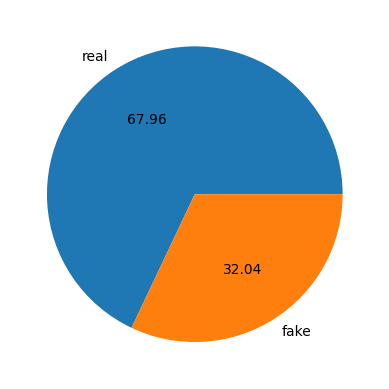

In [170]:
import matplotlib.pyplot as plt
plt.pie(df['sentiment'].value_counts(), labels=['real','fake'],autopct="%0.2f")
plt.show()

In [171]:
df = temp_df.iloc[:20000]

In [172]:
df.head()

,review,sentiment
0,"21st Century Wire says Ben Stein, reputable pr...",0
1,WASHINGTON (Reuters) - U.S. President Donald T...,1
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1
3,"On Monday, Donald Trump once again embarrassed...",0
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",1


In [179]:
df.drop_duplicates(inplace=True)

In [180]:
df.isnull().sum()

,0
review,0
sentiment,0


In [181]:
df = df.dropna()


In [182]:
df['review'][1]

'WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedented role in security discussions. Trump’s overhaul of the NSC, confirmed by a White House official, also elevated General Joseph Dunford, chairman of the Joint Chiefs of Staff and Dan Coats, the director of National Intelligence who heads all 17 U.S. intelligence agencies. The official said the change moves the NSC “back to its core function of what it’s supposed to do.” It also appears to mark a victory for national security adviser H.R. McMaster, who had told some national security experts he felt he was in a “battle to the death” with Bannon and others on the White House staff. Vice President Mike Pence said Bannon would continue to play an important role in policy and played down the shake-up as routine. “This is just a natural evolution to ensure t

In [183]:
import nltk

In [185]:
!pip install nltk

In [186]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [187]:
df['char_len'] = df['review'].apply(len)
df['word_len']=df['review'].apply(lambda x: len(x.split()))

In [188]:
df

,review,sentiment,char_len,word_len
0,"21st Century Wire says Ben Stein, reputable pr...",0,1028,171
1,WASHINGTON (Reuters) - U.S. President Donald T...,1,4820,771
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1,1848,304
3,"On Monday, Donald Trump once again embarrassed...",0,1244,183
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",1,3137,529
...,...,...,...,...
19994,Such a compassionate faith Bring an 8-year old...,0,991,167
19996,WHAT A NUT! New York s Mayor DeBlasio gives th...,0,1815,317
19997,HARARE (Reuters) - The resignation letter writ...,1,331,61
19998,Bill Maher and his guests took an opportunity ...,0,1844,324


In [189]:
df[['word_len','char_len']].describe()

,word_len,char_len
count,18627.000000,18627.000000
mean,408.300693,2486.808826
std,342.262103,2113.404853
min,0.000000,1.000000
25%,212.000000,1284.500000
50%,369.000000,2224.000000
75%,516.000000,3125.000000
max,8135.000000,51794.000000


In [190]:
df[df['sentiment']==1][['word_len','char_len']].describe()

,word_len,char_len
count,9507.000000,9507.000000
mean,385.323341,2380.157042
std,277.086055,1701.159152
min,26.000000,152.000000
25%,144.000000,884.000000
50%,359.000000,2224.000000
75%,528.000000,3251.500000
max,5172.000000,29781.000000


In [191]:
df[df['sentiment']==0][['word_len','char_len']].describe()

,word_len,char_len
count,9120.00000,9120.000000
mean,432.25307,2597.986294
std,397.63271,2466.175953
min,0.00000,1.000000
25%,267.00000,1589.000000
50%,374.00000,2223.500000
75%,509.00000,3044.250000
max,8135.00000,51794.000000


In [ ]:
import seaborn as sns
sns.histplot(df['word_len'], kde=True)

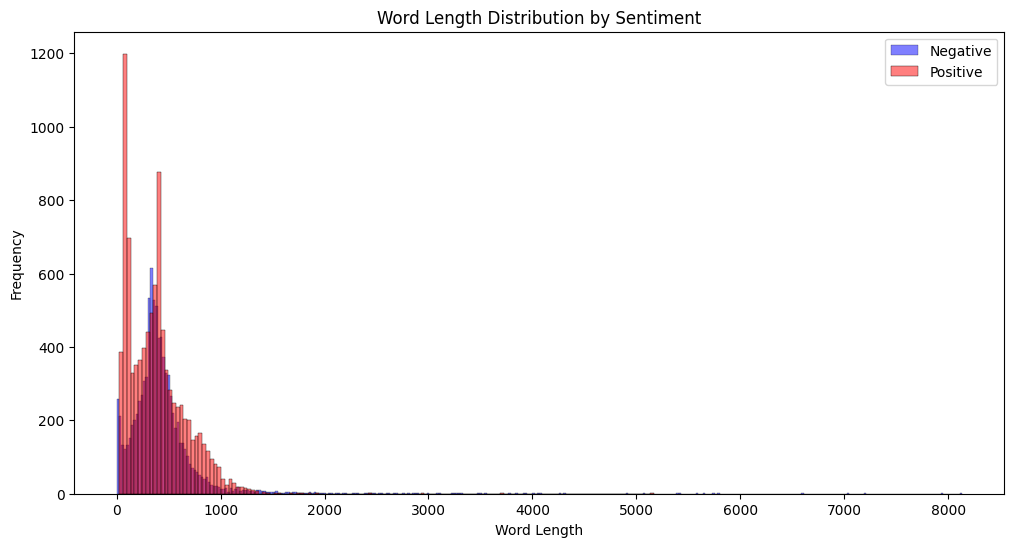

In [193]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['sentiment'] == 0]['word_len'], color='blue', alpha=0.5, label='Negative')
sns.histplot(df[df['sentiment'] == 1]['word_len'], color='red', alpha=0.5, label='Positive')
plt.legend()
plt.title("Word Length Distribution by Sentiment")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.show()


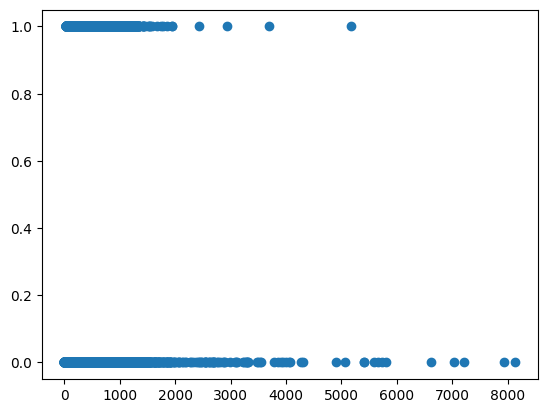

In [194]:
plt.scatter(df['word_len'],df['sentiment'])

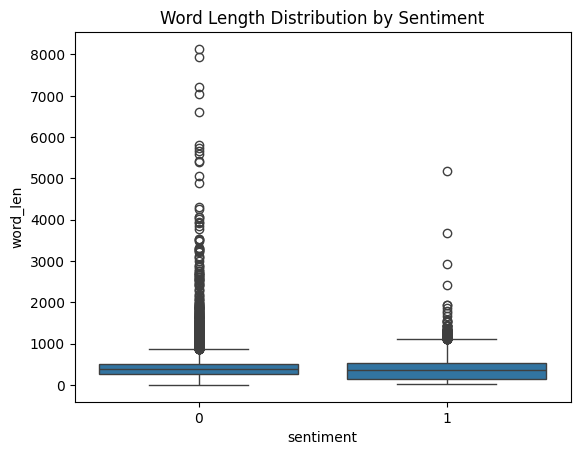

In [200]:
sns.boxplot(x="sentiment", y="word_len", data=df)
plt.title("Word Length Distribution by Sentiment")
plt.show()


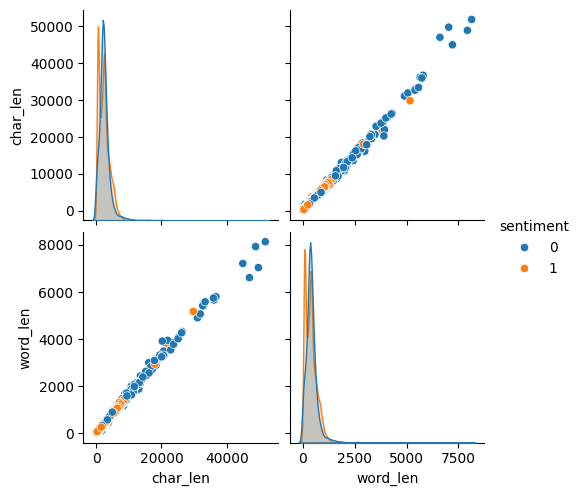

In [201]:
sns.pairplot(df,hue='sentiment')

In [205]:
df.drop_duplicates(inplace=True)

In [ ]:
# Basic Preprocessing
# Remove tags
# lowercase
# remove stopwords

In [208]:
import re

In [212]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer


nltk.download('stopwords')

# Initialize these outside the function so they don't reload on every single word
sw_list = set(stopwords.words('english')) # Using 'set' makes searching much faster
stemmer = PorterStemmer()

def preprocess_text(text):

    # 1. Convert to string and lowercase
    text = str(text).lower()

    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 3. Remove "CITY (Reuters) - " pattern
    text = re.sub(r'^.*?\(reuters\)\s*-\s*', '', text)

    # 4. Remove punctuation (Keep only alphabets and spaces)
    text = re.sub(r"[^a-zA-Z ]", " ", text)

    # 5. Remove stopwords AND Apply Stemming in one efficient loop
    words = text.split()
    cleaned_words = [stemmer.stem(word) for word in words if word not in sw_list]

    # 6. Rejoin into a single string
    return " ".join(cleaned_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [213]:
df['review'] = df['review'].apply(preprocess_text)

In [214]:
from collections import Counter
fake = " ".join(df[df['sentiment']==0]['review']).split()
real = " ".join(df[df['sentiment']==1]['review']).split()

Counter(fake).most_common(10)


[('trump', 33913),
 ('said', 13308),
 ('presid', 12005),
 ('peopl', 10831),
 ('one', 10267),
 ('state', 9805),
 ('would', 9439),
 ('like', 8977),
 ('say', 8395),
 ('time', 7883)]

In [215]:
Counter(real).most_common(10)

[('said', 43990),
 ('trump', 24232),
 ('u', 19493),
 ('state', 17056),
 ('would', 13932),
 ('presid', 13372),
 ('year', 10120),
 ('republican', 9821),
 ('govern', 9207),
 ('elect', 7996)]

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

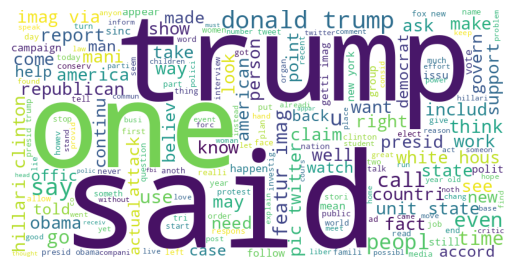

In [224]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


wc = WordCloud(width=800, height=400,background_color='white').generate(" ".join(fake))

plt.imshow(wc)
plt.axis('off')

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

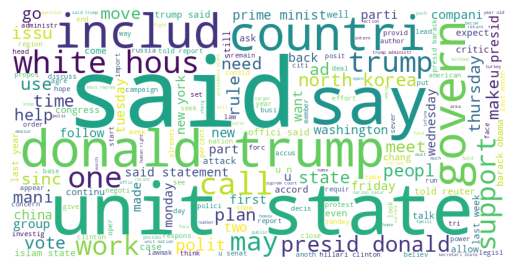

In [225]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400,background_color='white').generate(" ".join(real))

plt.imshow(wc)
plt.axis('off')

In [228]:
X = df['review']
y = df['sentiment']

In [229]:
X

,review
0,st centuri wire say ben stein reput professor ...
1,u presid donald trump remov chief strategist s...
2,puerto rico governor ricardo rossello said wed...
3,monday donald trump embarrass countri accident...
4,u presidenti candid go abroad sharpen foreign ...
...,...
19994,compassion faith bring year old girl clitorect...
19996,nut new york mayor deblasio give evil eye star...
19997,resign letter written zimbabwean presid robert...
19998,bill maher guest took opportun bill show real ...


In [230]:
y

,sentiment
0,0
1,1
2,1
3,0
4,1
...,...
19994,0
19996,0
19997,1
19998,0


In [231]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [232]:
y

array([0, 1, 1, ..., 1, 0, 1])

In [235]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Setup the Vectorizer (binary=True is the secret for BernoulliNB)
vectorizer = CountVectorizer(max_features=5000, binary=True)

# 2. Setup the Bernoulli model
bernoulli_model = BernoulliNB()

# 3. Create the unified Pipeline
bernoulli_pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('classifier', bernoulli_model)
])


# 5. Run 5-Fold Cross-Validation
print(f"Running Cross-Validation on {len(X)} rows...")
scores = cross_val_score(bernoulli_pipeline, X, y, cv=5, scoring='accuracy')

# 6. View the Results!
print(f"Accuracy for each of the 5 folds: {np.round(scores * 100, 2)}")
print(f"Average Accuracy: {np.mean(scores) * 100:.2f}%")
print(f"Variance (Stability): +/- {np.std(scores) * 100:.2f}%")

Running Cross-Validation on 18627 rows...
Accuracy for each of the 5 folds: [93.42 93.53 93.48 93.72 93.96]
Average Accuracy: 93.62%
Variance (Stability): +/- 0.20%


In [237]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Setup the Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# 2. Setup the Random Forest model
# n_estimators=100 creates 100 trees. n_jobs=-1 maximizes training speed.
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

# 3. Create the Pipeline
rf_pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('classifier', rf_model)
])

# 4. Define your data (assuming temp_df is still loaded)


# 5. Run 5-Fold Cross-Validation
print(f"Running Random Forest CV on {len(X)} rows...")
print("Grab a coffee, this will take a few minutes! ☕")
scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='accuracy')

# 6. View the Results!
print(f"Accuracy for each of the 5 folds: {np.round(scores * 100, 2)}")
print(f"Average Accuracy: {np.mean(scores) * 100:.2f}%")
print(f"Variance (Stability): +/- {np.std(scores) * 100:.2f}%")

Running Random Forest CV on 18627 rows...
Grab a coffee, this will take a few minutes! ☕
Accuracy for each of the 5 folds: [96.89 96.81 97.5  97.93 97.58]
Average Accuracy: 97.34%
Variance (Stability): +/- 0.43%


In [234]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [233]:
from sklearn.model_selection import cross_val_score

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [ ]:
X_train.shape

In [ ]:
X_train_b = cv.fit_transform(X_train['review'])
X_test_b = cv.transform(X_test['review'])

In [ ]:
X_num=X_train[["char_len","word_len"]]
X_test_num=X_test[["char_len","word_len"]]

In [ ]:
from scipy.sparse import hstack
X_train_bow=hstack([X_train_b,X_num])
X_test_bow=hstack([X_test_b,X_test_num])


In [ ]:
X_train_bow.shape

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

gnb.fit(X_train_bow,y_train)

In [ ]:
print(X_train.shape)   # should be (7986, n_features)
print(y_train.shape)   # should be (7986,)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
mnb=MultinomialNB()

mnb.fit(X_train_bow,y_train)

In [ ]:
from sklearn.naive_bayes import BernoulliNB
bnb=BernoulliNB()
bnb.fit(X_train_bow,y_train)

In [ ]:
y_pred_gnb = gnb.predict(X_test_bow)

from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_test,y_pred_gnb)

In [ ]:
y_pred_bnb = bnb.predict(X_test_bow)

from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_test,y_pred_bnb)

In [ ]:
y_pred_mnb = mnb.predict(X_test_bow)

from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_test,y_pred_mnb)

In [ ]:
print("accuracy : gnb",accuracy_score(y_test,y_pred_gnb))
print("accuracy : mnb",accuracy_score(y_test,y_pred_mnb))
print("accuracy : bnb",accuracy_score(y_test,y_pred_bnb))


In [ ]:
from sklearn.metrics import precision_recall_curve,roc_auc_score,roc_curve,recall_score,precision_score

In [ ]:
print("preccison : gnb",precision_score(y_test,y_pred_gnb))
print("preccison : mnb",precision_score(y_test,y_pred_mnb))
print("preccison : bnb",precision_score(y_test,y_pred_bnb))


In [ ]:

y_prob_mnb=mnb.predict_proba(X_train_bow)[:,1]
y_prob_mnb

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_mnb)
roc_auc_mnb = roc_auc_score(y_test, y_pred_mnb)

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc_mnb:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC for mnb)')
plt.legend(loc="lower right")
plt.show()


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_bnb)
roc_auc_bnb = roc_auc_score(y_test, y_pred_bnb)

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc_bnb:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC for bnb)')
plt.legend(loc="lower right")
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score_mnb=roc_auc_score(y_pred_mnb,y_test)
roc_auc_score_bnb=roc_auc_score(y_pred_bnb,y_test)

In [ ]:
print("roc_auc_area_mnb",roc_auc_score_mnb)
print("roc_auc_area_bnb",roc_auc_score_bnb)

In [ ]:
from sklearn.metrics import f1_score
print("F1_score : gnb",f1_score(y_test,y_pred_gnb))
print("F1_score : mnb",f1_score(y_test,y_pred_mnb))
print("F1_score : bnb",f1_score(y_test,y_pred_bnb))

print("accuracy : gnb",accuracy_score(y_test,y_pred_gnb))
print("accuracy : mnb",accuracy_score(y_test,y_pred_mnb))
print("accuracy : bnb",accuracy_score(y_test,y_pred_bnb))

print("preccison : gnb",precision_score(y_test,y_pred_gnb))
print("preccison : mnb",precision_score(y_test,y_pred_mnb))
print("preccison : bnb",precision_score(y_test,y_pred_bnb))

print("recall : gnb",recall_score(y_test,y_pred_gnb))
print("recall : mnb",recall_score(y_test,y_pred_mnb))
print("recall : bnb",recall_score(y_test,y_pred_bnb))
from sklearn.metrics import roc_auc_score
roc_auc_score_mnb=roc_auc_score(y_pred_mnb,y_test)
roc_auc_score_bnb=roc_auc_score(y_pred_bnb,y_test)




In [ ]:
confusion_matrix(y_test,y_pred_bnb)

In [ ]:
confusion_matrix(y_test,y_pred_gnb)

In [ ]:
confusion_matrix(y_test,y_pred_mnb)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
y_proba_bnb = bnb.predict_proba(X_test_bow)[:, 1]
# y_test: true labels
# y_proba: predicted probabilities for positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred_bnb)

# Youden’s J statistic = TPR - FPR
J = tpr - fpr
ix = J.argmax()   # index of best threshold
best_thresh = thresholds[ix]

print(f"Best Threshold = {best_thresh:.3f}")
print(f"ROC AUC Score = {roc_auc_score(y_test, y_pred_bnb):.3f}")

# Apply threshold
y_pred_opt = (y_pred_bnb>= best_thresh).astype(int)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_opt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_opt))


In [ ]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_bnb))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf.fit(X_train_bow,y_train)
y_pred = rf.predict(X_test_bow)
accuracy_score(y_test,y_pred)

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [200, 500],
    'max_depth': [20, 40, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_bow, y_train)

print(grid.best_params_)
print(grid.best_score_)

In [ ]:
cv = CountVectorizer(max_features=3800)

X_train_bow = cv.fit_transform(X_train['review']).toarray()
X_test_bow = cv.transform(X_test['review']).toarray()

rf = RandomForestClassifier()

rf.fit(X_train_bow,y_train)
y_pred = rf.predict(X_test_bow)
accuracy_score(y_test,y_pred)

In [ ]:
print("recall : rf",recall_score(y_test,y_pred))
print("f1score",f1_score(y_test,y_pred))

In [ ]:
from sklearn.naive_bayes import BernoulliNB
bnb=BernoulliNB()
bnb.fit(X_train_bow,y_train)

In [ ]:
y_pred_bnb = bnb.predict(X_test_bow)

from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_test,y_pred_bnb)

In [ ]:
cv = CountVectorizer(max_features=3000)

X_train_bow = cv.fit_transform(X_train['review']).toarray()
X_test_bow = cv.transform(X_test['review']).toarray()


## Using TfIdf

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer()

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train['review']).toarray()
X_test_tfidf = tfidf.transform(X_test['review'])

In [ ]:
rf = RandomForestClassifier()

rf.fit(X_train_tfidf,y_train)
y_pred = rf.predict(X_test_tfidf)

accuracy_score(y_test,y_pred)

In [ ]:
from sklearn.naive_bayes import BernoulliNB
bnb=BernoulliNB()
bnb.fit(X_train_tfidf,y_train)

In [ ]:
y_pred_bnb_tfidf = bnb.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_test,y_pred_bnb_tfidf)

In [ ]:
y_pred_bnb_tfidf = bnb.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_test,y_pred_bnb_tfidf)

In [ ]:
from sklearn.svm import LinearSVC
svm=LinearSVC()
svm.fit(X_train_tfidf,y_train)
y_pred_svm = svm.predict(X_test_tfidf)
accuracy_score(y_test,y_pred_svm)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

for c in [0.01, 0.1, 1, 5, 10]:
    svm = LinearSVC(C=c, random_state=42)
    svm.fit(X_train_tfidf, y_train)
    y_pred = svm.predict(X_test_tfidf)
    print(c, accuracy_score(y_test, y_pred))

In [ ]:
accuracy_score(y_test,y_pred_svm)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_tfidf, y_train)

y_pred = lr.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
import gensim

In [ ]:
from gensim.models import Word2Vec,KeyedVectors

In [ ]:
model = KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin',binary=True,limit=500000)

In [ ]:
model['cricket'].shape

In [ ]:
from nltk.corpus import stopwords

sw_list = stopwords.words('english')

In [ ]:
sw_list

In [ ]:
# Remove stopwords

X_train = X_train['review'].apply(lambda x: [item for item in x.split() if item not in sw_list]).apply(lambda x:" ".join(x))
# Remove stopwords

X_test = X_test['review'].apply(lambda x: [item for item in x.split() if item not in sw_list]).apply(lambda x:" ".join(x))

In [ ]:
import spacy
import en_core_web_sm
# Load the spacy model. This takes a few seconds.
nlp = en_core_web_sm.load()
# Process a sentence using the model
doc = nlp(X_train.values[0])
print(doc.vector)

In [ ]:
!pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-2.2.0/en_core_web_sm-2.2.5.tar.gz

In [ ]:
!python -m spacy download en_core_web_sm

In [ ]:
input_arr = []
for item in X_train.values:
    doc = nlp(item)
    input_arr.append(doc.vector)

In [ ]:
input_arr = np.array(input_arr)

In [ ]:
input_arr.shape

In [ ]:
input_test_arr = []
for item in X_test.values:
    doc = nlp(item)
    input_test_arr.append(doc.vector)

In [ ]:
input_test_arr = np.array(input_test_arr)

In [ ]:
input_test_arr.shape

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
gnb = GaussianNB()
gnb.fit(input_arr,y_train)

In [ ]:
y_pred = gnb.predict(input_test_arr)
accuracy_score(y_test,y_pred)